In [5]:
import sys
!{sys.executable} -m pip install folium
import matplotlib.pyplot as plt
import pandas as pd
import folium
df = pd.read_csv("Dataset.csv")
df = df.dropna(subset=["Latitude", "Longitude"])
map_center = [df["Latitude"].mean(), df["Longitude"].mean()]
restaurant_map = folium.Map(location=map_center, zoom_start=5)
for i, row in df.head(500).iterrows():
    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        popup=row["Restaurant Name"]
    ).add_to(restaurant_map)
restaurant_map

In [6]:
city_count = df["City"].value_counts()
print(city_count.head(10))

New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: City, dtype: int64


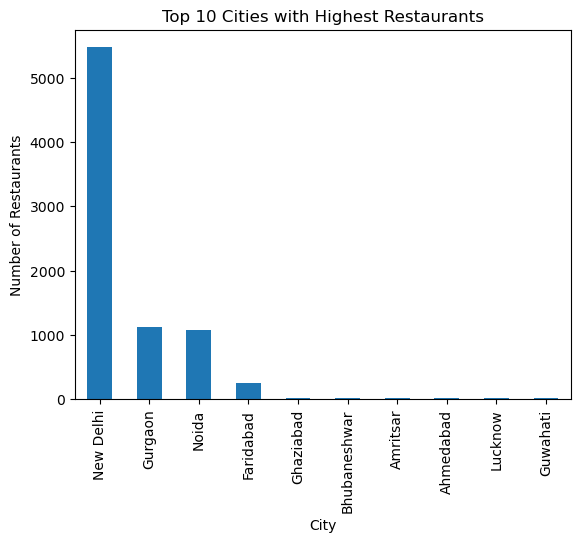

In [7]:
city_count.head(10).plot(kind='bar')
plt.title("Top 10 Cities with Highest Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.show()

In [8]:
country_count = df["Country Code"].value_counts()
print(country_count)

1      8652
216     434
215      80
30       60
214      60
189      60
148      40
208      34
14       24
162      22
94       21
184      20
166      20
191      20
37        4
Name: Country Code, dtype: int64


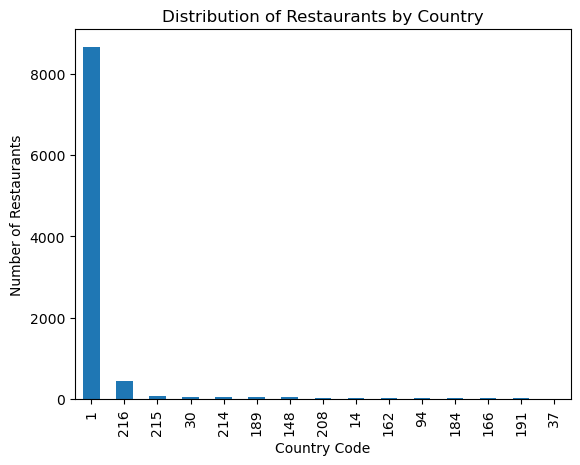

In [9]:
country_count.plot(kind='bar')
plt.title("Distribution of Restaurants by Country")
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")
plt.show()

In [10]:
df["Aggregate rating"] = pd.to_numeric(df["Aggregate rating"], errors='coerce')

In [11]:
correlation = df[["Latitude", "Longitude", "Aggregate rating"]].corr()
print(correlation)

                  Latitude  Longitude  Aggregate rating
Latitude          1.000000   0.043207          0.000516
Longitude         0.043207   1.000000         -0.116818
Aggregate rating  0.000516  -0.116818          1.000000


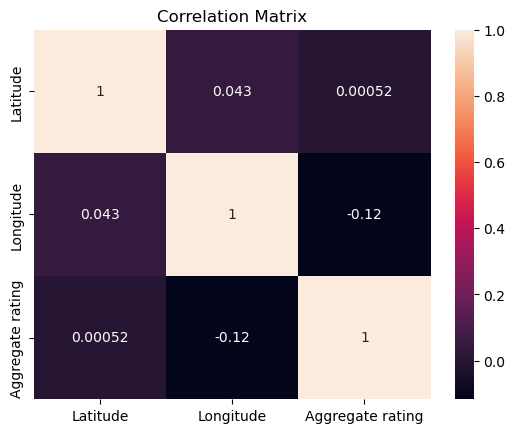

In [12]:
import seaborn as sns

sns.heatmap(correlation, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [13]:
avg_rating_city = df.groupby("City")["Aggregate rating"].mean().sort_values(ascending=False)
print(avg_rating_city.head(10))

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Tagaytay City       4.500000
Secunderabad        4.500000
Name: Aggregate rating, dtype: float64


In [14]:
avg_rating_country = df.groupby("Country Code")["Aggregate rating"].mean()
print(avg_rating_country)

Country Code
1      2.523324
14     3.658333
30     3.763333
37     3.575000
94     4.295238
148    4.262500
162    4.468182
166    4.060000
184    3.575000
189    4.210000
191    3.870000
208    4.300000
214    4.233333
215    4.087500
216    4.004378
Name: Aggregate rating, dtype: float64
